# Continuous Glucose Monitoring — Clustering Analysis

This notebook clusters daily glucose profiles from FreeStyle Libre 
continuous glucose monitors collected over 13 days (days 2-14) 
in the AI4Food crossover study.

## Method
K-Means clustering (k=2) on standardized 15-minute interval 
glucose curves. Days with less than 12 hours of valid data excluded.
Sleep window (01:30–07:00) highlighted for biological context.

Loading glucose data...
Total valid day-curves loaded: 1118

Cluster 0: High glucose (mean = 107.3 mg/dL)
Cluster 1: Low glucose  (mean = 93.9 mg/dL)
Cluster sizes: {0: 552, 1: 566}


C:\Users\Attioui Hicham\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


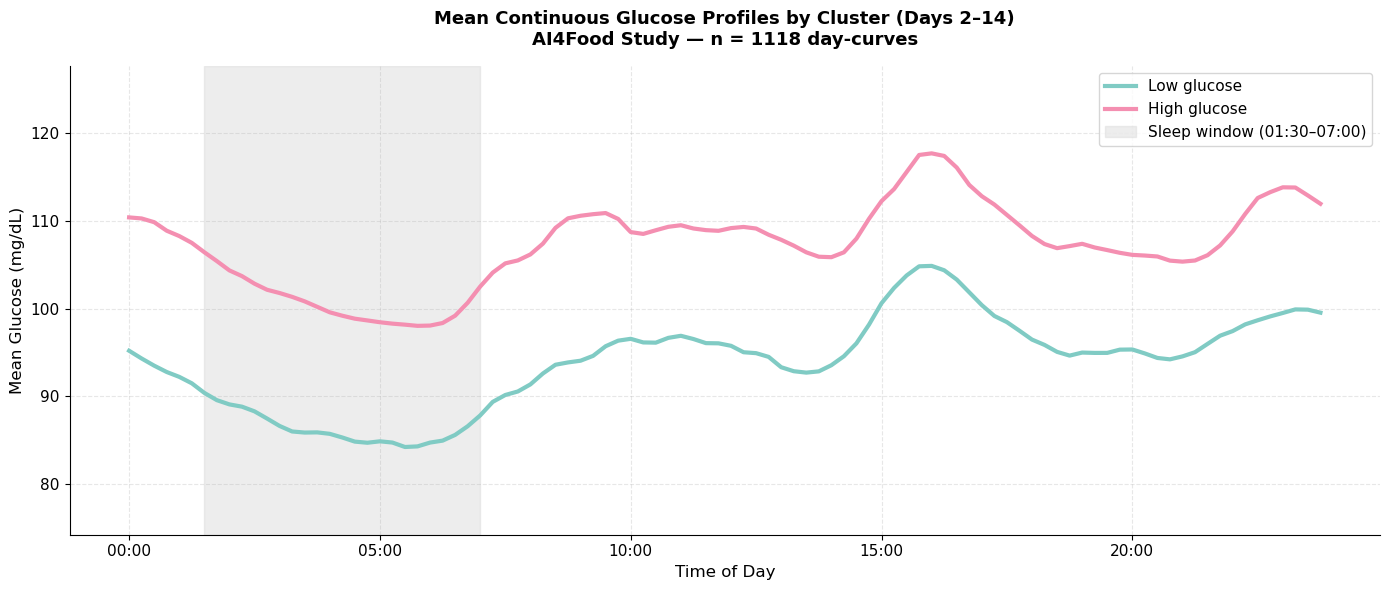

Figure saved: figures/glucose_cluster_curves.png


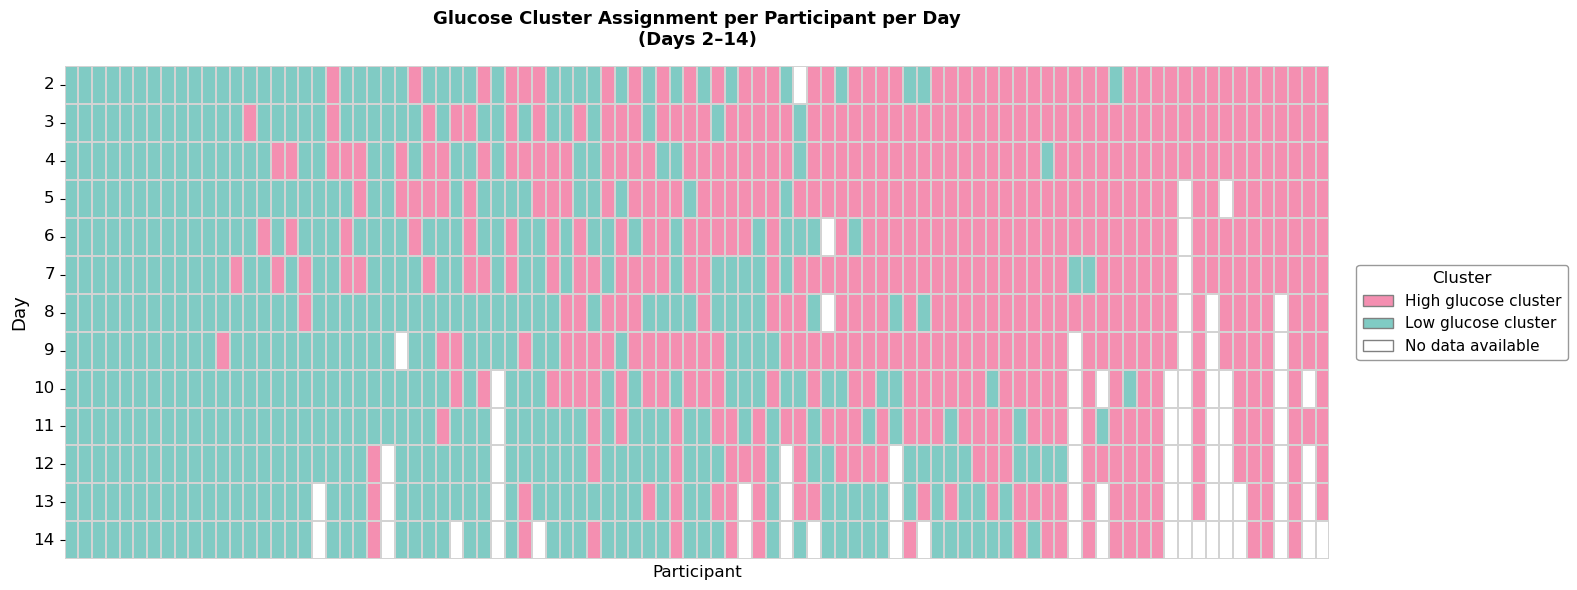

Figure saved: figures/glucose_cluster_heatmap.png

Cluster assignments saved: data/glucose_cluster_aligned.xlsx
Total rows: 1118 | Participants: 92


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# CONFIGURATION

GROUP1_FOLDER = "data/DS4_glucose/group_1"
GROUP2_FOLDER = "data/DS4_glucose/group_2"
OUTPUT_EXCEL  = "data/glucose_cluster_aligned.xlsx"

N_CLUSTERS  = 2
MIN_POINTS  = 24       
DAY_START   = 2
DAY_END     = 14
SLEEP_START = "01:30"
SLEEP_END   = "07:00"
COLOR_HIGH  = "#F48FB1"
COLOR_LOW   = "#80CBC4"

os.makedirs("figures", exist_ok=True)

# LOAD AND PROCESS DATA

time_bins   = pd.date_range("00:00", "23:59", freq="15min").time
time_labels = [t.strftime("%H:%M") for t in time_bins]

def load_glucose_data(folder_path):
    """
    Load and preprocess continuous glucose monitoring data.
    - Keeps days 2-14 with >= 6h of valid data (MIN_POINTS)
    - Bins into 15-minute intervals
    - Interpolates missing values aggressively
    """
    records = []
    for file_path in glob.glob(os.path.join(folder_path, "*.csv")):
        participant_id = os.path.basename(file_path).split('_')[0]
        df = pd.read_csv(file_path)

        required_cols = {'timestamp', 'glucose_value_in_mg_dl'}
        if not required_cols.issubset(df.columns):
            continue

        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        df = df.dropna(subset=['timestamp', 'glucose_value_in_mg_dl'])
        df['timestamp'] = df['timestamp'].dt.tz_localize(None)
        df['date']      = df['timestamp'].dt.date
        df              = df.sort_values('timestamp')

        unique_dates   = df['date'].drop_duplicates().sort_values()
        date_to_day    = {date: i + 1 for i, date in enumerate(unique_dates)}
        df['day_rank'] = df['date'].map(date_to_day)

        df = df[(df['day_rank'] >= DAY_START) & (df['day_rank'] <= DAY_END)]
        df['time_bin'] = df['timestamp'].dt.floor('15min').dt.time

        for date, group in df.groupby('date'):
            day   = int(group['day_rank'].iloc[0])
            curve = (group
                     .groupby('time_bin')['glucose_value_in_mg_dl']
                     .mean()
                     .reindex(time_bins))

            if curve.notna().sum() >= MIN_POINTS:
                curve = curve.ffill().bfill().interpolate(
                    method='linear', limit_direction='both'
                )
                records.append({
                    'participant_id': participant_id,
                    'day':            day,
                    'date':           date,
                    'glucose_curve':  curve.values
                })
    return records

print("Loading glucose data...")
records  = load_glucose_data(GROUP1_FOLDER)
records += load_glucose_data(GROUP2_FOLDER)
print(f"Total valid day-curves loaded: {len(records)}")

# CLUSTERING

X      = np.array([r['glucose_curve'] for r in records])
ids    = [r['participant_id'] for r in records]
days   = [r['day']  for r in records]
dates  = [r['date'] for r in records]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

aligned_df    = pd.DataFrame(X, columns=time_labels)
aligned_df['cluster'] = clusters
cluster_means = aligned_df.drop(columns='cluster').groupby(aligned_df['cluster']).mean()

cluster_avg  = cluster_means.mean(axis=1)
high_cluster = int(cluster_avg.idxmax())
low_cluster  = int(cluster_avg.idxmin())
color_map    = {high_cluster: COLOR_HIGH, low_cluster: COLOR_LOW}

print(f"\nCluster {high_cluster}: High glucose (mean = {cluster_avg[high_cluster]:.1f} mg/dL)")
print(f"Cluster {low_cluster}: Low glucose  (mean = {cluster_avg[low_cluster]:.1f} mg/dL)")
print(f"Cluster sizes: {dict(zip(*np.unique(clusters, return_counts=True)))}")

# FIGURE 1 : MEAN GLUCOSE CURVES PER CLUSTER

fig, ax = plt.subplots(figsize=(14, 6))

for cid in [low_cluster, high_cluster]:
    label = "High glucose" if cid == high_cluster else "Low glucose"
    ax.plot(time_labels, cluster_means.loc[cid],
            color=color_map[cid], linewidth=3, label=label)

try:
    start_idx = time_labels.index(SLEEP_START)
    end_idx   = time_labels.index(SLEEP_END)
    ax.axvspan(start_idx, end_idx,
               color='lightgray', alpha=0.4, label='Sleep window (01:30–07:00)')
except ValueError:
    pass

hourly_pos    = [i for i in range(len(time_labels)) if i % 20 == 0]
hourly_labels = [time_labels[i] for i in hourly_pos]
ax.set_xticks(hourly_pos)
ax.set_xticklabels(hourly_labels, rotation=0, fontsize=11)

y_min = cluster_means.values.min() - 10
y_max = cluster_means.values.max() + 10
ax.set_ylim(y_min, y_max)
ax.yaxis.set_tick_params(labelsize=11)

ax.set_title(
    f"Mean Continuous Glucose Profiles by Cluster (Days {DAY_START}–{DAY_END})\n"
    f"AI4Food Study — n = {len(records)} day-curves",
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel("Time of Day", fontsize=12)
ax.set_ylabel("Mean Glucose (mg/dL)", fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/glucose_cluster_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/glucose_cluster_curves.png")

# FIGURE 2 : HEATMAP OF CLUSTER ASSIGNMENTS

heatmap_df = pd.DataFrame({
    'participant_id': ids,
    'day':            days,
    'cluster':        clusters
})

heatmap_matrix = heatmap_df.pivot_table(
    index='day', columns='participant_id', values='cluster'
)

high_counts    = (heatmap_matrix == high_cluster).sum()
sort_order     = high_counts.sort_values(ascending=False).index
heatmap_matrix = heatmap_matrix[sort_order]

cmap = ListedColormap([COLOR_LOW, COLOR_HIGH])

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [10, 1]})
ax_heat   = axes[0]
ax_legend = axes[1]

sns.heatmap(
    heatmap_matrix,
    cmap=cmap, cbar=False,
    vmin=0, vmax=1,
    linewidths=0.3, linecolor='lightgray',
    ax=ax_heat,
    mask=heatmap_matrix.isna()
)

ax_heat.set_facecolor('white')
ax_heat.set_title(
    f"Glucose Cluster Assignment per Participant per Day\n(Days {DAY_START}–{DAY_END})",
    fontsize=13, fontweight='bold', pad=15
)
ax_heat.set_xlabel("Participant", fontsize=12)
ax_heat.set_ylabel("Day", fontsize=13)
ax_heat.set_xticklabels([], fontsize=0)
ax_heat.set_xticks([])
ax_heat.set_yticklabels(
    ax_heat.get_yticklabels(),
    rotation=0, fontsize=12
)

legend_elements = [
    Patch(facecolor=COLOR_HIGH, edgecolor='gray', label='High glucose cluster'),
    Patch(facecolor=COLOR_LOW,  edgecolor='gray', label='Low glucose cluster'),
    Patch(facecolor='white',    edgecolor='gray', label='No data available'),
]
ax_legend.axis('off')
ax_legend.legend(
    handles=legend_elements,
    loc='center',
    fontsize=11,
    frameon=True,
    title='Cluster',
    title_fontsize=12,
    edgecolor='gray'
)

plt.tight_layout()
plt.savefig("figures/glucose_cluster_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/glucose_cluster_heatmap.png")

# EXPORT CLUSTER ASSIGNMENTS

output_df = pd.DataFrame({
    'participant_id':  ids,
    'day':             days,
    'glucose_cluster': clusters,
    'recording_date':  [d.strftime('%d-%m-%Y') for d in dates]
})

output_df['sleep_day'] = output_df['day'] - 1
output_df = output_df[output_df['sleep_day'] >= 0]
output_df = output_df[['participant_id', 'sleep_day',
                        'glucose_cluster', 'recording_date']]

output_df.to_excel(OUTPUT_EXCEL, index=False)
print(f"\nCluster assignments saved: {OUTPUT_EXCEL}")
print(f"Total rows: {len(output_df)} | "
      f"Participants: {output_df['participant_id'].nunique()}")